In [158]:
import importlib, traceback

try:
    import water_sim_basic
    importlib.reload(water_sim_basic)
except Exception:
    traceback.print_exc()

In [159]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from water_sim_basic import (
    generate_polyhedron,
    compute_vertex_normals_and_volume,
    step, step_test, step_test2
    )
    
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [160]:
# --- RESET FOR DEBUG ---
n_verts = 50
radius = 1.0
x, faces, neighbours = generate_polyhedron(n_vertices=n_verts, radius=radius) #

# Drop from Z=1 (Center is at 0, so we add 2 to clear the floor)
x[:, 2] += 1.50 
v = np.zeros_like(x)

# Calculate the 'ideal' volume to maintain
_, V_initial = compute_vertex_normals_and_volume(x, faces) #
print(f"Initial Volume: {V_initial:.2f}")
print(f"Initial Vertices:\n{x}")

dt = 0.00001
num_steps = 1000

Initial Volume: 3.71
Initial Vertices:
[[ 0.          0.          2.5       ]
 [-0.20646329 -0.18913728  2.46      ]
 [ 0.03426374  0.39041772  2.42      ]
 [ 0.28899243 -0.37693948  2.38      ]
 [-0.53429216  0.09450876  2.34      ]
 [ 0.5062532   0.32203683  2.3       ]
 [-0.16872282 -0.6276405   2.26      ]
 [-0.3198575   0.6158662   2.22      ]
 [ 0.6887218  -0.25152007  2.18      ]
 [-0.71024394 -0.29317838  2.1399999 ]
 [ 0.3390768   0.72458744  2.1       ]
 [ 0.24795447 -0.7905179   2.06      ]
 [-0.73903424  0.42828545  2.02      ]
 [ 0.8568069   0.18836659  1.98      ]
 [-0.51646495 -0.73461825  1.94      ]
 [-0.11778199  0.9089155   1.9       ]
 [ 0.71338105 -0.6012383   1.86      ]
 [-0.9466085  -0.03914523  1.8199999 ]
 [ 0.68047625  0.67716473  1.78      ]
 [-0.04484141 -0.9697367   1.74      ]
 [-0.62776417  0.7522713   1.7       ]
 [ 0.97830147 -0.13162908  1.66      ]
 [-0.81492674 -0.5670048   1.62      ]
 [ 0.2187779   0.9724897   1.58      ]
 [ 0.49678296 -0.86695254

In [136]:
from water_sim_basic import (
    compute_lumped_areas,
    build_laplacian_matrix,
    estimate_mesh_quality,
    apply_local_volume_correction,
    apply_implicit_mean_curvature_flow,
    apply_global_volume_correction,
    step_test
)

In [132]:
# 1. Physics Constants
g = np.array([0.0, 0.0, -9.81], dtype=np.float32)
gamma = 0.005
mu = 1.0
nu = 0.0
nu_extra = 0.50
max_speed = 20.0
epsilon = 2
density = 1.0

# 2. Geometry
areas = compute_lumped_areas(x, faces)
L = build_laplacian_matrix(x, faces)
quality_ratio = estimate_mesh_quality(faces, x)
eta = nu + (nu_extra if quality_ratio > 2.6 else 0.0)

# 3. Forces
inv_mass = 1.0 / np.where(areas > 1e-8, areas, 1e-8)
f_visc = (L @ v) * inv_mass[:, np.newaxis] * eta

# 4. Integrate Velocity
v_next = (v + (g + f_visc) * dt) * (1.0 - mu * dt)
speed = np.linalg.norm(v_next, axis=1)
speed_scale = np.minimum(1.0, max_speed / np.maximum(speed, 1e-8))
v_next *= speed_scale[:, np.newaxis]

# 5. Volume Preservation Constraints
v_trans = np.mean(v_next, axis=0)
v_rel = v_next - v_trans
v_rel = apply_local_volume_correction(x, v_rel, faces)
v_next = v_rel + v_trans

print(f"After Force Integration - v_rel:\n{v_rel[:4]}")
print(f"After Force Integration - Velocities:\n{v_next[:4]}")

# 6. Predict position and compute collision mask BEFORE curvature flow
x_pred = x + v_next * dt
collision_mask = x_pred[:, 2] < 0.0   # moved up from step 7

# 7. Implicit mean curvature flow — single call, pinning ground vertices
x_next = apply_implicit_mean_curvature_flow(
    x_pred, faces, dt, gamma, density, fixed_vertices=collision_mask
)
print(f"After Mean Curvature Flow - Vertices:\n{x_next[:4]}")

# Reject curvature flow result if it moved vertices unreasonably far
max_reasonable_disp = 1.0   # metres — tune to your scale
disp = x_next - x_pred
if np.max(np.linalg.norm(disp, axis=1)) > max_reasonable_disp:
    print("WARNING: curvature flow displacement too large, skipping")
    x_next = x_pred.copy()
    disp = np.zeros_like(x_pred)
else:
    # Clamp and feed back into velocity only if displacement is reasonable
    edges = np.vstack((faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]))
    edge_len = np.linalg.norm(x_pred[edges[:, 0]] - x_pred[edges[:, 1]], axis=1)
    max_disp = 0.25 * max(np.mean(edge_len), 1e-5)
    disp_len = np.linalg.norm(disp, axis=1, keepdims=True)
    disp_scale = np.minimum(1.0, max_disp / np.maximum(disp_len, 1e-8))
    disp *= disp_scale
    x_next = x_pred + disp
v_next = v_next + disp / dt

print(f"After Curvature Flow + Disp Clamp - Vertices:\n{x_next[:4]}")
print(f"After Curvature Flow + Disp Clamp - Velocities:\n{v_next[:4]}")

# 8. Ground collision response
x_next[collision_mask, 2] = 0.0
v_next[collision_mask, 2] = np.maximum(0.0, v_next[collision_mask, 2])
v_next[collision_mask, :2] *= 0.5

# 9. Ground friction
friction_mask = collision_mask & (np.linalg.norm(v_next[:, :2], axis=1) > epsilon)
friction_scale = np.maximum(0.0, 1.0 - epsilon)
v_next[friction_mask, :2] *= friction_scale / np.linalg.norm(
    v_next[friction_mask, :2], axis=1, keepdims=True
)

# 10. Global volume correction
x_next = apply_global_volume_correction(
    x_next, faces, V_initial, ground_mask=collision_mask, radial_spread=0.3
)
x_next[collision_mask, 2] = 0.0   # re-enforce ground plane after volume correction

if not np.all(np.isfinite(x_next)) or not np.all(np.isfinite(v_next)):
    x = x.copy()
    v = np.zeros_like(v)
else:
    x = x_next
    v = v_next

print(f"After 1 Step - Vertices:\n{x[:8]}")
print(f"After 1 Step - Velocities:\n{v[:8]}")
print(f"After 1 Step - Volume: {compute_vertex_normals_and_volume(x, faces)[1]:.2f}")

After Force Integration - v_rel:
[[-1.0419403e-15 -6.6480106e-16 -1.4563378e-11]
 [ 3.0774801e-15  3.3998325e-15 -1.4562494e-11]
 [ 1.3156162e-16 -4.7949548e-15 -1.4562400e-11]
 [-3.4337621e-15  3.6225325e-15 -1.4562308e-11]]
After Force Integration - Velocities:
[[-1.0419403e-15 -6.6480106e-16 -9.8099023e-05]
 [ 3.0774801e-15  3.3998325e-15 -9.8099023e-05]
 [ 1.3156162e-16 -4.7949548e-15 -9.8099023e-05]
 [-3.4337621e-15  3.6225325e-15 -9.8099023e-05]]
After Mean Curvature Flow - Vertices:
[[ 2.0386260e-08  1.2417268e-09  2.5000052e+00]
 [-2.0646332e-01 -1.8913727e-01  2.4599955e+00]
 [ 3.4263961e-02  3.9041805e-01  2.4199984e+00]
 [ 2.8899252e-01 -3.7693968e-01  2.3800008e+00]]
After Curvature Flow + Disp Clamp - Vertices:
[[ 2.0386260e-08  1.2417268e-09  2.5000052e+00]
 [-2.0646332e-01 -1.8913727e-01  2.4599955e+00]
 [ 3.4263961e-02  3.9041805e-01  2.4199984e+00]
 [ 2.8899252e-01 -3.7693968e-01  2.3800008e+00]]
After Curvature Flow + Disp Clamp - Velocities:
[[ 2.0386260e-03  1.24172

In [137]:
x, v = step_test(x, v, faces, neighbours, V_initial, dt)
print(f"After 1 Step - Vertices:\n{x[:16]}")
print(f"After 1 Step - Velocities:\n{v[:16]}")
print(f"After 1 Step - Volume: {compute_vertex_normals_and_volume(x, faces)[1]:.2f}")

After Force Integration - v_rel:
[[-1.0419403e-15 -6.6480106e-16 -1.4563378e-11]
 [ 3.0774801e-15  3.3998325e-15 -1.4562494e-11]
 [ 1.3156162e-16 -4.7949548e-15 -1.4562400e-11]
 [-3.4337621e-15  3.6225325e-15 -1.4562308e-11]]
After Force Integration - Velocities:
[[-1.0419403e-15 -6.6480106e-16 -9.8099023e-05]
 [ 3.0774801e-15  3.3998325e-15 -9.8099023e-05]
 [ 1.3156162e-16 -4.7949548e-15 -9.8099023e-05]
 [-3.4337621e-15  3.6225325e-15 -9.8099023e-05]]
L @ x_pred (first 4 vertices):
[[-0.06761747 -0.0043073  -0.3735761 ]
 [ 0.09343293  0.09049316 -0.33630654]
 [-0.01165314 -0.17883874 -0.389474  ]
 [-0.14248566  0.1728684  -0.41912374]]
Max |L @ x_pred|: 0.539783
After Mean Curvature Flow - Vertices:
[[ 2.0386260e-08  1.2417268e-09  2.5000052e+00]
 [-2.0646332e-01 -1.8913727e-01  2.4599955e+00]
 [ 3.4263961e-02  3.9041805e-01  2.4199984e+00]
 [ 2.8899252e-01 -3.7693968e-01  2.3800008e+00]]
After Curvature Flow + Disp Clamp - Vertices:
[[ 2.0386260e-08  1.2417268e-09  2.5000052e+00]
 [-

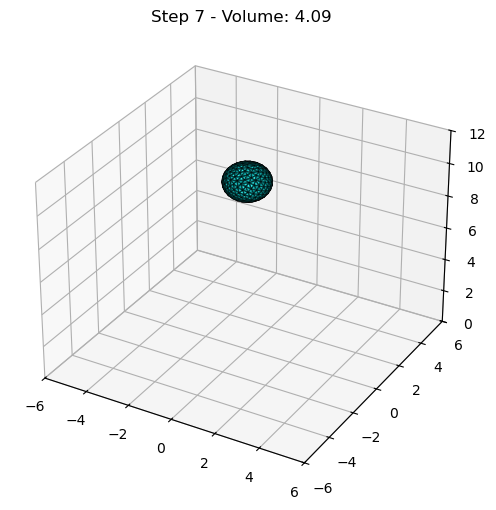

[[[-0.5353762   0.41468385 11.201401  ]
  [-0.36968076  0.21416171 11.369637  ]
  [-0.57194954  0.18245451 11.266169  ]]

 [[-0.9807658  -0.15381096 10.345723  ]
  [-0.95731884 -0.28495404 10.51371   ]
  [-0.90791684 -0.3541996  10.241757  ]]

 [[-0.35581458 -0.9317555  10.537708  ]
  [-0.27276835 -0.94103396 10.265745  ]
  [-0.14775816 -0.988485   10.433714  ]]

 ...

 [[-0.72432363  0.6226404  10.761685  ]
  [-0.8642015   0.4650136  10.657717  ]
  [-0.8093087   0.58685875 10.489704  ]]

 [[-0.72432363  0.6226404  10.761685  ]
  [-0.57738256  0.5858932  11.033687  ]
  [-0.5508639   0.733237   10.865967  ]]

 [[-0.72432363  0.6226404  10.761685  ]
  [-0.74268365  0.48279434 10.9299345 ]
  [-0.57738256  0.5858932  11.033687  ]]]


KeyboardInterrupt: 

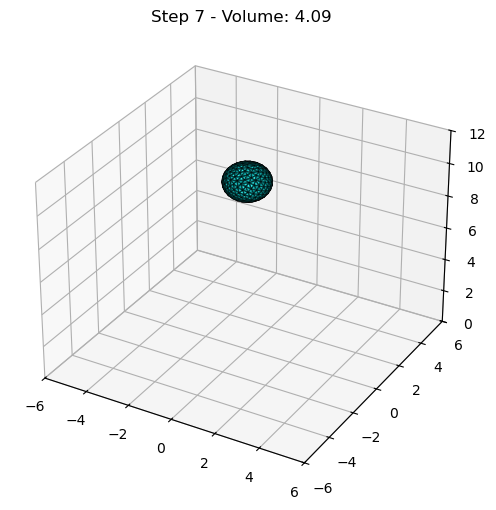

In [174]:
# --- Initialization ---
n_verts = 250
radius = 1.0
x, faces, neighbours = generate_polyhedron(n_vertices=n_verts, radius=radius) #

# Drop from Z=1 (Center is at 0, so we add 2 to clear the floor)
x[:, 2] += 10.50
v = np.zeros_like(x)

# Calculate the 'ideal' volume to maintain
_, V_initial = compute_vertex_normals_and_volume(x, faces) #
print(f"Initial Volume: {V_initial:.2f}")
print(f"Initial Vertices:\n{x}")

dt = 0.01
num_steps = 1000

# --- Plotting Setup ---
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

for s in range(199):
    # Update Physics
    x, v = step_test(x, v, faces, neighbours, V_initial, dt)
    # Visualization
    ax.clear()
    
    # Create triangle mesh for plotting
    poly = Poly3DCollection(x[faces], alpha=0.5, edgecolor='k', facecolors='cyan')
    ax.add_collection3d(poly)
    
    # Fix the viewing window
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_zlim(0, 12)
    _, V_current = compute_vertex_normals_and_volume(x, faces)
    ax.set_title(f"Step {s} - Volume: {V_current:.2f}")
    
    # Refresh the notebook display
    display.clear_output(wait=True)
    display.display(plt.gcf())

    print(x[faces])
    
plt.close() # Prevents extra static plot from showing